# Purchase Intent Model (Multi-output)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score,
                              confusion_matrix, classification_report)

df = pd.read_csv("../data/processed/cleaned_users.csv")
print(df.shape)
df.head()


(12000, 25)


,Customer_ID,Age,Gender,Occupation,City,Monthly_Income,Annual_Income,Family_Size,Current_Housing_Status,Plot_Budget,...,Expected_Purchase_Timeline,Lead_Source,Previous_Enquiry,Site_Visit,Negotiation_Done,Booking_Done,Purchase_Probability,Purchase_Intent,Purchased,Purchase_Value
0,CUST_20988,21,Male,Unknown,Mumbai,131500.0,1578000,2,Owned Flat/House,7020000.0,...,1-3 years,Google & Social Media Ads,No,No,No,No,0.0639,Low,No,0
1,CUST_16662,29,Male,Real Estate & Construction,Kolkata,43800.0,525600,4,Owned Flat/House,2000000.0,...,1-3 years,Magicbricks / Real Estate Portal,Yes,No,No,No,0.0668,Low,No,0
2,CUST_10543,50,Male,Retail & Commerce,Noida,179000.0,2149200,2,Owned Flat/House,5710000.0,...,0-6 months,Channel Partner / Broker,No,Yes,Yes,Yes,0.9900,High,Yes,5550000
3,CUST_15741,44,Male,Retail & Commerce,Pune,45700.0,548400,4,Living with Parents,2300000.0,...,6-12 months,Print / Newspaper Ad,Yes,No,No,No,0.2293,Low,No,0
4,CUST_16911,38,Male,Business Owner,Ahmedabad,219400.0,2632800,4,Rented,4730000.0,...,0-6 months,Magicbricks / Real Estate Portal,No,Yes,No,No,0.7678,High,Yes,8930000


---

# Regression

In [2]:
input_features = ["Age", "Monthly_Income", "Annual_Income", "Family_Size",
                   "Plot_Budget", "Preferred_Plot_Size_SqFt", "Distance_to_City_Center_km",
                   "Gender", "Occupation", "City", "Current_Housing_Status",
                   "Preferred_Location", "Purpose", "Loan_Required",
                   "Expected_Purchase_Timeline", "Lead_Source",
                   "Previous_Enquiry", "Site_Visit", "Negotiation_Done"]

target_cols = ["Purchase_Probability", "Purchase_Value"]

cat_cols = ["Gender", "Occupation", "City", "Current_Housing_Status", "Preferred_Location",
            "Purpose", "Loan_Required", "Expected_Purchase_Timeline", "Lead_Source",
            "Previous_Enquiry", "Site_Visit", "Negotiation_Done"]

X = df[input_features].copy()
y = df[target_cols].copy()

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(X.shape, y.shape)
X.head()


(12000, 73) (12000, 2)


,Age,Monthly_Income,Annual_Income,Family_Size,Plot_Budget,Preferred_Plot_Size_SqFt,Distance_to_City_Center_km,Gender_Male,Gender_Unknown,Occupation_Banker,...,Expected_Purchase_Timeline_1-3 years,Expected_Purchase_Timeline_6-12 months,Expected_Purchase_Timeline_>3 years,Lead_Source_Direct Walk-in / Exhibition,Lead_Source_Google & Social Media Ads,Lead_Source_Magicbricks / Real Estate Portal,Lead_Source_Print / Newspaper Ad,Previous_Enquiry_Yes,Site_Visit_Yes,Negotiation_Done_Yes
0,21,131500.0,1578000,2,7020000.0,1500.0,33.8,True,False,False,...,True,False,False,False,True,False,False,False,False,False
1,29,43800.0,525600,4,2000000.0,600.0,17.0,True,False,False,...,True,False,False,False,False,True,False,True,False,False
2,50,179000.0,2149200,2,5710000.0,1200.0,20.3,True,False,False,...,False,False,False,False,False,False,False,False,True,True
3,44,45700.0,548400,4,2300000.0,1000.0,40.9,True,False,False,...,False,True,False,False,False,False,True,True,False,False
4,38,219400.0,2632800,4,4730000.0,1500.0,22.8,True,False,False,...,False,False,False,False,False,True,False,False,True,False


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape


(9600, 73)

### PCA check

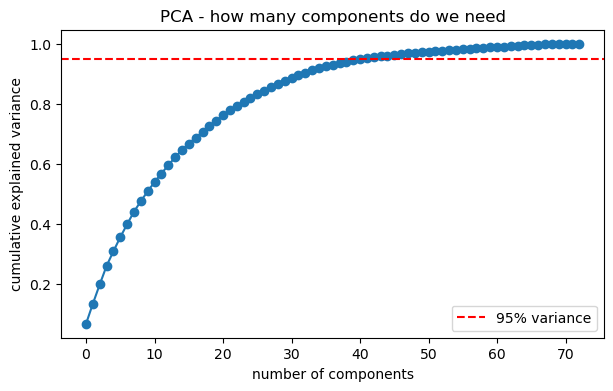

components needed for 95% variance: 42


In [4]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.legend()
plt.title("PCA - how many components do we need")
plt.show()

n_components_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print("components needed for 95% variance:", n_components_95)


In [5]:
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


### baseline models

Purchase_Probability and Purchase_Value are on very different scales (0-1 vs
lakhs/crores), but r2_score handles that fine since it's scale independent per target.

In [6]:
def evaluate_multi(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    per_target_r2 = r2_score(y_te, pred, multioutput="raw_values")
    avg_r2 = r2_score(y_te, pred, multioutput="uniform_average")
    mae = mean_absolute_error(y_te, pred, multioutput="raw_values")
    print(f"{name}: avg R2={avg_r2:.3f}")
    for col, r2, m in zip(target_cols, per_target_r2, mae):
        print(f"    {col}: R2={r2:.3f}  MAE={m:.3f}")
    return {"model": model, "avg_r2": avg_r2, "per_target_r2": per_target_r2}

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, random_state=42)),
}

print("---without PCA---")
results_no_pca = {}
for name, model in models.items():
    results_no_pca[name] = evaluate_multi(model, X_train_scaled, X_test_scaled, y_train, y_test, name)


---without PCA---
Linear Regression: avg R2=0.629
    Purchase_Probability: R2=0.841  MAE=0.093
    Purchase_Value: R2=0.417  MAE=2361172.673
Random Forest: avg R2=0.670
    Purchase_Probability: R2=0.841  MAE=0.092
    Purchase_Value: R2=0.499  MAE=1906536.354
Gradient Boosting: avg R2=0.661
    Purchase_Probability: R2=0.862  MAE=0.084
    Purchase_Value: R2=0.459  MAE=1943736.401


In [7]:
print("---with PCA (Random Forest only, as a quick check)---")
results_pca = {"Random Forest": evaluate_multi(RandomForestRegressor(n_estimators=200, random_state=42), X_train_pca, X_test_pca, y_train, y_test, "Random Forest")}


---with PCA (Random Forest only, as a quick check)---
Random Forest: avg R2=0.601
    Purchase_Probability: R2=0.805  MAE=0.106
    Purchase_Value: R2=0.396  MAE=2213533.562


In [8]:
print("Random Forest without PCA:", round(results_no_pca["Random Forest"]["avg_r2"], 3))
print("Random Forest with PCA:   ", round(results_pca["Random Forest"]["avg_r2"], 3))


Random Forest without PCA: 0.67
Random Forest with PCA:    0.601


### GridSearchCV tuning

In [9]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15],
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=2, scoring="r2")
rf_grid.fit(X_train_scaled, y_train)

print("best params:", rf_grid.best_params_)
print("best cv avg r2:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
tuned_result = evaluate_multi(best_rf, X_train_scaled, X_test_scaled, y_train, y_test, "Tuned Random Forest")


best params: {'max_depth': 10, 'n_estimators': 200}
best cv avg r2: 0.6419881310423312
Tuned Random Forest: avg R2=0.668
    Purchase_Probability: R2=0.831  MAE=0.096
    Purchase_Value: R2=0.505  MAE=1876709.343


In [10]:
gb_param_grid = {
    "estimator__n_estimators": [100],
    "estimator__learning_rate": [0.05, 0.1],
    "estimator__max_depth": [2, 3],
}

gb_grid = GridSearchCV(
    MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    gb_param_grid, cv=2, scoring="r2", 
)
gb_grid.fit(X_train_scaled, y_train)

print("best params:", gb_grid.best_params_)
print("best cv avg r2:", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_
gb_tuned_result = evaluate_multi(best_gb, X_train_scaled, X_test_scaled, y_train, y_test, "Tuned Gradient Boosting")


best params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}
best cv avg r2: 0.6630069756499318
Tuned Gradient Boosting: avg R2=0.668
    Purchase_Probability: R2=0.855  MAE=0.089
    Purchase_Value: R2=0.480  MAE=1992273.448


In [11]:
final_results = {
    "Linear Regression": results_no_pca["Linear Regression"],
    "Tuned Random Forest": tuned_result,
    "Tuned Gradient Boosting": gb_tuned_result,
}
final_df = pd.DataFrame({k: {"avg_r2": v["avg_r2"]} for k, v in final_results.items()}).T
final_df = final_df.sort_values("avg_r2", ascending=False)
final_df


,avg_r2
Tuned Random Forest,0.668180
Tuned Gradient Boosting,0.667769
Linear Regression,0.628808


### best model - predicted vs actual, per target

best model: Tuned Random Forest


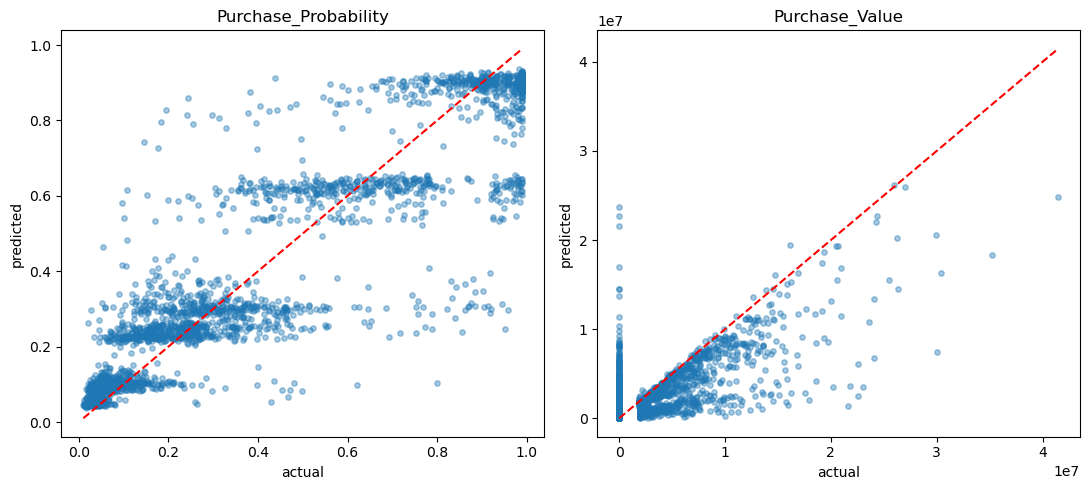

In [12]:
best_name = final_df.index[0]
best_model = final_results[best_name]["model"]
print("best model:", best_name)

pred = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(11,5))
for ax, col, i in zip(axes, target_cols, range(2)):
    ax.scatter(y_test[col], pred[:, i], alpha=0.4, s=15)
    lims = [y_test[col].min(), y_test[col].max()]
    ax.plot(lims, lims, "r--")
    ax.set_title(col)
    ax.set_xlabel("actual")
    ax.set_ylabel("predicted")
plt.tight_layout()
plt.show()


In [13]:
import joblib

joblib.dump(best_model, "../models/purchase_multi_output_model.pkl")
joblib.dump(scaler, "../models/purchase_reg_scaler.pkl")
joblib.dump(list(X.columns), "../models/purchase_reg_columns.pkl")
joblib.dump(target_cols, "../models/purchase_reg_targets.pkl")
print("saved:", best_name)


saved: Tuned Random Forest


---

# Part 2 - Classification (HIGH / MEDIUM / LOW purchase intent)

Same real inputs as Part 1, predicting the Purchase_Intent category directly.
Not using Purchase_Probability as a feature here - confirmed earlier it's just
Purchase_Intent's source column, using it would be a 100% accuracy cheat.

In [14]:
Xc = df[input_features].copy()
yc = df["Purchase_Intent"].copy()

Xc = pd.get_dummies(Xc, columns=cat_cols, drop_first=True)
yc.value_counts()


Purchase_Intent
Low       6611
High      3549
Medium    1840
Name: count, dtype: int64

In [15]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

clf_scaler = MinMaxScaler()
Xc_train_scaled = clf_scaler.fit_transform(Xc_train)
Xc_test_scaled = clf_scaler.transform(Xc_test)


In [16]:
def evaluate_clf(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    print(f"{name}: accuracy={acc:.3f}")
    return {"model": model, "acc": acc, "pred": pred}

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

clf_results = {}
for name, model in clf_models.items():
    clf_results[name] = evaluate_clf(model, Xc_train_scaled, Xc_test_scaled, yc_train, yc_test, name)


Logistic Regression: accuracy=0.837
Random Forest: accuracy=0.843
Gradient Boosting: accuracy=0.840


### GridSearchCV on the Random Forest classifier

In [17]:
rf_clf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 15],
}

rf_clf_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_clf_grid, cv=2, scoring="accuracy")
rf_clf_search.fit(Xc_train_scaled, yc_train)
print("best params:", rf_clf_search.best_params_)
print("best cv accuracy:", rf_clf_search.best_score_)

best_rf_clf = rf_clf_search.best_estimator_
tuned_clf_result = evaluate_clf(best_rf_clf, Xc_train_scaled, Xc_test_scaled, yc_train, yc_test, "Tuned Random Forest")


best params: {'max_depth': 15, 'n_estimators': 200}
best cv accuracy: 0.8444791666666667
Tuned Random Forest: accuracy=0.841


In [18]:
clf_final = {**clf_results, "Tuned Random Forest": tuned_clf_result}
clf_summary = pd.DataFrame({k: {"accuracy": v["acc"]} for k, v in clf_final.items()}).T
clf_summary = clf_summary.sort_values("accuracy", ascending=False)
clf_summary


,accuracy
Random Forest,0.842500
Tuned Random Forest,0.841250
Gradient Boosting,0.840000
Logistic Regression,0.836667


best classifier: Random Forest

              precision    recall  f1-score   support

        High       0.85      0.86      0.86       710
         Low       0.88      0.97      0.92      1322
      Medium       0.58      0.36      0.44       368

    accuracy                           0.84      2400
   macro avg       0.77      0.73      0.74      2400
weighted avg       0.82      0.84      0.83      2400



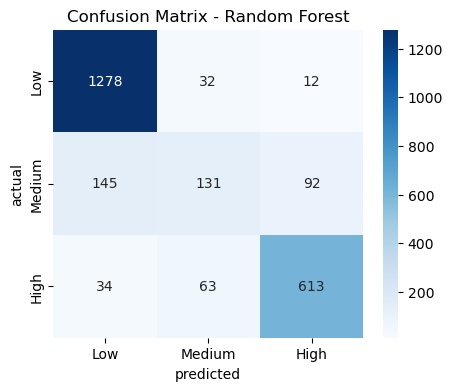

In [19]:
best_clf_name = clf_summary.index[0]
best_clf_model = clf_final[best_clf_name]["model"]
pred = clf_final[best_clf_name]["pred"]

print("best classifier:", best_clf_name)
print()
print(classification_report(yc_test, pred))

cm = confusion_matrix(yc_test, pred, labels=["Low","Medium","High"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title(f"Confusion Matrix - {best_clf_name}")
plt.show()


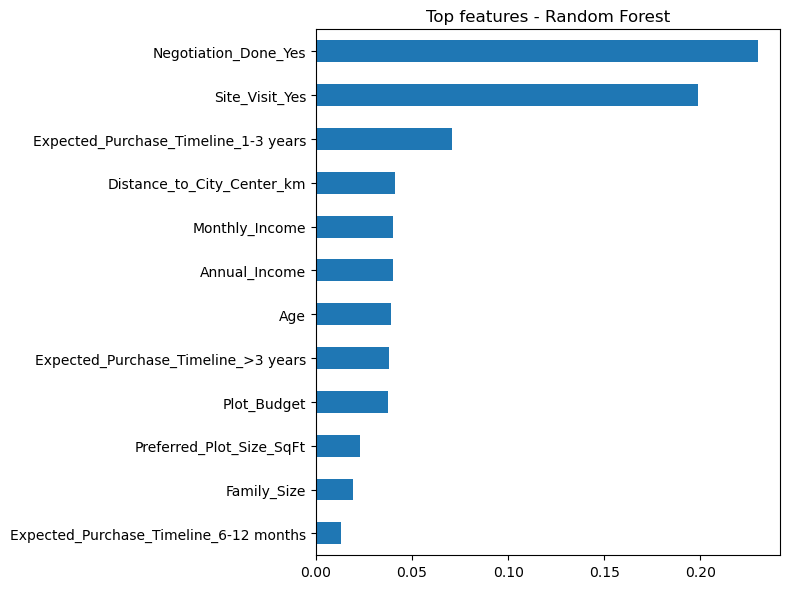

In [20]:
if hasattr(best_clf_model, "feature_importances_"):
    importances = pd.Series(best_clf_model.feature_importances_, index=Xc.columns)
    importances.sort_values(ascending=False).head(12).sort_values().plot(kind="barh", figsize=(8,6))
    plt.title(f"Top features - {best_clf_name}")
    plt.tight_layout()
    plt.show()


In [21]:
joblib.dump(best_clf_model, "../models/purchase_intent_classifier.pkl")
joblib.dump(clf_scaler, "../models/purchase_intent_clf_scaler.pkl")
joblib.dump(list(Xc.columns), "../models/purchase_intent_clf_columns.pkl")
print("saved:", best_clf_name)


saved: Random Forest
